In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Grove3=cv2.imread('../data/all-frames-colour/Grove3/frame07.png')
Rubberwhale=cv2.imread('../data/all-frames-colour/RubberWhale/frame07.png')
Urban2=cv2.imread('../data/all-frames-colour/Urban2/frame07.png')


def apply_harris_corner_detector(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    corners = cv2.goodFeaturesToTrack(gray, 70, 0.01, 10, useHarrisDetector=True)
    corners = np.int0(corners)
    corner_coordinates = np.zeros((img.shape[0], img.shape[1]))
    corners = sorted(corners, key=lambda x: x[0][0])
    for i in corners:
        x, y = i.ravel()
        corner_coordinates[y, x] = 1
        cv2.circle(img, (x, y), 3, 255, -1)
    return img, corner_coordinates
    

imgs=[Grove3,Rubberwhale,Urban2]
for i in range(len(imgs)):
    image,corners=apply_harris_corner_detector(imgs[i])
    if i==0:
        cv2.imwrite('../results/2.1/'+"Grove3"+'.png',image)
    elif i==1:
        cv2.imwrite('../results/2.1/'+"Rubberwhale"+'.png',image)
    else:
        cv2.imwrite('../results/2.1/'+"Urban2"+'.png',image)
    


In [2]:
UNKNOWN_FLOW_THRESH = 1e7
def show_flow(filename):
    """
    visualize optical flow map using matplotlib
    :param filename: optical flow file
    :return: None
    """
    flow = read_flow(filename)
    img = flow_to_image(flow)
    plt.imshow(img)
    plt.show()

def read_flow(filename):
    """
    read optical flow from Middlebury .flo file
    :param filename: name of the flow file
    :return: optical flow data in matrix
    """
    f = open(filename, 'rb')
    magic = np.fromfile(f, np.float32, count=1)
    data2d = None

    if 202021.25 != magic:
        print ('Magic number incorrect. Invalid .flo file')
    else:
        w = int(np.fromfile(f, np.int32, count=1)[0])
        h = int(np.fromfile(f, np.int32, count=1)[0])
        #print("Reading %d x %d flo file" % (h, w))
        data2d = np.fromfile(f, np.float32, count=2 * w * h)
        # reshape data into 3D array (columns, rows, channels)
        data2d = np.resize(data2d, (h, w, 2))
    f.close()
    return data2d

def flow_to_image(flow):
    """
    Convert flow into middlebury color code image
    :param flow: optical flow map
    :return: optical flow image in middlebury color
    """
    u = flow[:, :, 0]
    v = flow[:, :, 1]

    maxu = -999.
    maxv = -999.
    minu = 999.
    minv = 999.

    idxUnknow = (abs(u) > UNKNOWN_FLOW_THRESH) | (abs(v) > UNKNOWN_FLOW_THRESH)
    u[idxUnknow] = 0
    v[idxUnknow] = 0

    maxu = max(maxu, np.max(u))
    minu = min(minu, np.min(u))

    maxv = max(maxv, np.max(v))
    minv = min(minv, np.min(v))

    rad = np.sqrt(u ** 2 + v ** 2)
    maxrad = max(-1, np.max(rad))

    u = u/(maxrad + np.finfo(float).eps)
    v = v/(maxrad + np.finfo(float).eps)

    img = compute_color(u, v)

    idx = np.repeat(idxUnknow[:, :, np.newaxis], 3, axis=2)
    img[idx] = 0

    return np.uint8(img)


def compute_color(u, v):
    """
    compute optical flow color map
    :param u: optical flow horizontal map
    :param v: optical flow vertical map
    :return: optical flow in color code
    """
    [h, w] = u.shape
    img = np.zeros([h, w, 3])
    nanIdx = np.isnan(u) | np.isnan(v)
    u[nanIdx] = 0
    v[nanIdx] = 0

    colorwheel = make_color_wheel()
    ncols = np.size(colorwheel, 0)

    rad = np.sqrt(u**2+v**2)

    a = np.arctan2(-v, -u) / np.pi

    fk = (a+1) / 2 * (ncols - 1) + 1

    k0 = np.floor(fk).astype(int)

    k1 = k0 + 1
    k1[k1 == ncols+1] = 1
    f = fk - k0

    for i in range(0, np.size(colorwheel,1)):
        tmp = colorwheel[:, i]
        col0 = tmp[k0-1] / 255
        col1 = tmp[k1-1] / 255
        col = (1-f) * col0 + f * col1

        idx = rad <= 1
        col[idx] = 1-rad[idx]*(1-col[idx])
        notidx = np.logical_not(idx)

        col[notidx] *= 0.75
        img[:, :, i] = np.uint8(np.floor(255 * col*(1-nanIdx)))

    return img


def make_color_wheel():
    """
    Generate color wheel according Middlebury color code
    :return: Color wheel
    """
    RY = 15
    YG = 6
    GC = 4
    CB = 11
    BM = 13
    MR = 6

    ncols = RY + YG + GC + CB + BM + MR

    colorwheel = np.zeros([ncols, 3])

    col = 0

    # RY
    colorwheel[0:RY, 0] = 255
    colorwheel[0:RY, 1] = np.transpose(np.floor(255*np.arange(0, RY) / RY))
    col += RY

    # YG
    colorwheel[col:col+YG, 0] = 255 - np.transpose(np.floor(255*np.arange(0, YG) / YG))
    colorwheel[col:col+YG, 1] = 255
    col += YG

    # GC
    colorwheel[col:col+GC, 1] = 255
    colorwheel[col:col+GC, 2] = np.transpose(np.floor(255*np.arange(0, GC) / GC))
    col += GC

    # CB
    colorwheel[col:col+CB, 1] = 255 - np.transpose(np.floor(255*np.arange(0, CB) / CB))
    colorwheel[col:col+CB, 2] = 255
    col += CB

    # BM
    colorwheel[col:col+BM, 2] = 255
    colorwheel[col:col+BM, 0] = np.transpose(np.floor(255*np.arange(0, BM) / BM))
    col += + BM

    # MR
    colorwheel[col:col+MR, 2] = 255 - np.transpose(np.floor(255 * np.arange(0, MR) / MR))
    colorwheel[col:col+MR, 0] = 255

    return colorwheel

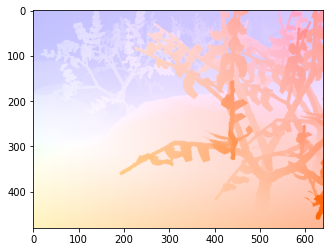

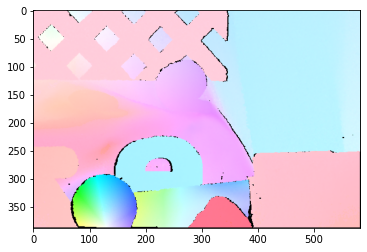

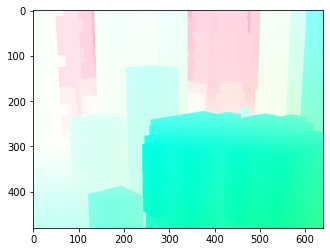

In [3]:

show_flow('../data/ground-truth-flow/Grove3/flow10.flo')
show_flow('../data/ground-truth-flow/RubberWhale/flow10.flo')
show_flow('../data/ground-truth-flow/Urban2/flow10.flo')

def LucasKanadeForwardAdditive(Img1, Img2, windowSize, tau):
    Img1 = cv2.cvtColor(Img1, cv2.COLOR_BGR2GRAY)
    Img2 = cv2.cvtColor(Img2, cv2.COLOR_BGR2GRAY)
    Img1 = Img1 / 255.
    Img2 = Img2 / 255.
    mask=np.zeros((Img1.shape[0],Img1.shape[1],2))


    for i in range(windowSize, Img1.shape[0] - windowSize):
        for j in range(windowSize, Img1.shape[1] - windowSize):
            window1 = Img1[i - windowSize:i + windowSize + 1, j - windowSize:j + windowSize + 1]
            window2 = Img2[i - windowSize:i + windowSize + 1, j - windowSize:j + windowSize + 1]
            Ix = cv2.Sobel(window1, cv2.CV_64F, 1, 0, ksize=3)
            Iy = cv2.Sobel(window1, cv2.CV_64F, 0, 1, ksize=3)
            It = window2 - window1
            Ix = Ix.flatten()
            Iy = Iy.flatten()
            It = It.flatten()
            A = np.vstack((Ix, Iy)).T
            b = -It
            if np.min(np.linalg.eigvals(np.dot(A.T, A))) > tau:
                u = np.dot(np.linalg.inv(np.dot(A.T, A)), np.dot(A.T, b))
                mask[i,j]=u                
    return mask
            
def plot_quiver(img1, img2, windowSize, tau,corners,img_set,frame_num):
    flow = LucasKanadeForwardAdditive(img1, img2, windowSize, tau)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 15))
    ax1.imshow(img1)
    ax2.imshow(img1)
    
    
    
    for i in range(0, np.size(corners, 0)):
        for j in range(0, np.size(corners, 1)):
            if corners[i, j] == 1:
                u = flow[i, j, 0]
                v = flow[i, j, 1]
                ax1.quiver(j, i, u, v, color='r', scale=2, width=0.005)
                

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    corners = cv2.goodFeaturesToTrack(gray1, 70, 0.01, 10, useHarrisDetector=True)
    lk_params = dict( winSize = (10, 10),
                  maxLevel = 2,
                  criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
                              10, 0.03))
    p1, st, err = cv2.calcOpticalFlowPyrLK(gray1, gray2, corners,None, **lk_params)
    old_corners = corners[st == 1]
    new_corners = p1[st == 1]


 
    for i in range(0, np.size(old_corners, 0)):
        x = int(old_corners[i,  0])
        y = int(old_corners[i,  1])
        u=new_corners[i,0]-x
        v=new_corners[i,1]-y
        if img_set=='Urban2' or img_set=='Grove3':
            ax2.quiver(x, y, u, v, color='r',  scale=60, width=0.005)
        else:
            ax2.quiver(x, y, u, v, color='r',  scale=18, width=0.005)
    ax1.set_title('My Implementation')
    ax2.set_title('OpenCV Implementation')
    folder_name = '../results/2.2/' + img_set + '/'
    filename=str(frame_num)+"-"+str(frame_num+1)+'.png'
    plt.savefig(folder_name+filename)
    plt.close()

   
    
def all_frames_flow(img_set):
    img1=cv2.imread('../data/all-frames-colour/'+str(img_set)+'/'+'frame07.png')
    img2=cv2.imread('../data/all-frames-colour/'+str(img_set)+'/'+'frame08.png')

    
    for i in range (7,14):
        s1='../data/all-frames-colour/'+str(img_set)+'/'+'frame'
        s2 = '../data/all-frames-colour/'+str(img_set)+'/'+'frame0'
        if i<10:
            s=s2+str(i)+'.png'
        else:
            s=s1+str(i)+'.png'
        img1=cv2.imread(s)
        if i+1<10:
            s=s2+str(i+1)+'.png'
        else:
            s=s1+str(i+1)+'.png'
        img2=cv2.imread(s)
        img1_copy=img1.copy()
        image,corners=apply_harris_corner_detector(img1_copy)
        plot_quiver(img1, img2, 10, 0.01,corners,img_set,i)

all_frames_flow('Grove3')
all_frames_flow('RubberWhale')
all_frames_flow('Urban2')

In [4]:
def calculate_error(img_set,windowSize):
    gt_flow=read_flow('../data/ground-truth-flow/'+str(img_set)+'/'+'flow10.flo')
    img1=cv2.imread('../data/all-frames-colour/'+str(img_set)+'/'+'frame10.png')
    img2=cv2.imread('../data/all-frames-colour/'+str(img_set)+'/'+'frame11.png')
    img1_copy=img1.copy()
    image,corners=apply_harris_corner_detector(img1_copy)
    flow = LucasKanadeForwardAdditive(img1, img2, windowSize, 0.01)
    error=0
    count=0
    # change the nan values to 0 in gt_flow
    gt_flow[np.isnan(gt_flow)] = 0

    for i in range(0, np.size(corners, 0)):
        for j in range(0, np.size(corners, 1)):
            if corners[i, j] == 1 :
                u = flow[i, j, 0]
                v = flow[i, j, 1]
                u_gt=gt_flow[i, j, 0]
                v_gt=gt_flow[i, j, 1]
                if u_gt>100 or v_gt>100:
                    continue
                error+=np.sqrt((u-u_gt)**2+(v-v_gt)**2)
                count+=1
    return error/count

grove_errors=[]
rubberwhale_errors=[]
urban2_errors=[]
window_size=[8,10,12,16,20]
datasets=["Grove3","RubberWhale","Urban2"]
for dataset in datasets:
    for window in window_size:
        error=calculate_error(dataset,window)
        if dataset=="Grove3":
            grove_errors.append(error)
        elif dataset=="RubberWhale":
            rubberwhale_errors.append(error)
        else:
            urban2_errors.append(error)


In [5]:
df = pd.DataFrame({'Window Size':window_size,'Grove3':grove_errors,'RubberWhale':rubberwhale_errors,'Urban2':urban2_errors},index=[1,2,3,4,5])
print(df)

   Window Size    Grove3  RubberWhale     Urban2
1            8  3.542527     0.988953  14.489106
2           10  3.542056     0.989338  14.485553
3           12  3.543193     0.991568  14.490197
4           16  3.546174     0.993805  14.500810
5           20  3.546116     1.000373  14.503330


# Task-3: Multi-Scale Coarse-to-fine Optical Flow

In [6]:
def warpImage(img,flow):
    u=flow[:,:,0]
    v=flow[:,:,1]
    x,y=np.meshgrid(np.arange(0,u.shape[1]),np.arange(0,u.shape[0]))
    x=x+u
    y=y+v
    x= x.astype(np.float32)
    y= y.astype(np.float32)
    warped_img=cv2.remap(img,x,y,cv2.INTER_LINEAR)
    return warped_img

def OpticalFlowRefine(Img1, Img2, windowSize, u0, v0):
    u=u0
    v=v0
    new_flow=LucasKanadeForwardAdditive(Img1, Img2, windowSize, 0.01)
    u=u+new_flow[:,:,0]
    v=v+new_flow[:,:,1]
    return u,v


   
def MultiScaleLucasKanade(img1, img2, windowSize,numLevels):
    img1 = cv2.GaussianBlur(img1, (5, 5), 0)
    img2 = cv2.GaussianBlur(img2, (5, 5), 0)
    Img1=img1.copy()
    Img2=img2.copy()
    for i in range(0, numLevels):
        img1 = cv2.pyrDown(img1)
        img2 = cv2.pyrDown(img2)
    flow = LucasKanadeForwardAdditive(img1, img2, windowSize, 0.01)
    
    for i in range(numLevels - 1, -1, -1):
        img1=Img1.copy()
        img2=Img2.copy()
        for j in range(0, i):
            img1 = cv2.pyrDown(img1)
            img2 = cv2.pyrDown(img2)
        flow = cv2.pyrUp(flow)
        flow = flow[0:img1.shape[0], 0:img1.shape[1], :]


        img1=warpImage(img1, flow)
        u,v=OpticalFlowRefine(img1, img2, windowSize, flow[:,:,0], flow[:,:,1])
        flow[:,:,0]=u
        flow[:,:,1]=v
        
    return flow

def plot_flow(img1,img2, flow, corners, img_set, frame_num):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 15))
    ax1.imshow(img1)
    ax2.imshow(img1)
    ax3.imshow(img1)
    for i in range(0, np.size(corners, 0)):
        for j in range(0, np.size(corners, 1)):
            if corners[i, j] == 1 :
                x = j
                y = i
                u = flow[i, j, 0]
                v = flow[i, j, 1]
                ax1.quiver(x, y, u, v, color='r',  scale=4, width=0.005)
    ax1.set_title('MultiScaleLucasKanade')
    ax2.set_title('SingleScaleLucasKanade')
    ax3.set_title('OpenCV Implementation')

    for i in range(0, np.size(corners, 0)):
        for j in range(0, np.size(corners, 1)):
            if corners[i, j] == 1:
                u = flow[i, j, 0]
                v = flow[i, j, 1]
                ax2.quiver(j, i, u, v, color='r', scale=4, width=0.005)
                

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    corners = cv2.goodFeaturesToTrack(gray1, 70, 0.01, 10, useHarrisDetector=True)
    lk_params = dict( winSize = (15, 15),
                  maxLevel = 2,
                  criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
                              10, 0.03))
    p1, st, err = cv2.calcOpticalFlowPyrLK(gray1, gray2, corners,None, **lk_params)
    old_corners = corners[st == 1]
    new_corners = p1[st == 1]


 
    for i in range(0, np.size(old_corners, 0)):
        x = int(old_corners[i,  0])
        y = int(old_corners[i,  1])
        u=new_corners[i,0]-x
        v=new_corners[i,1]-y
        if img_set=='Urban2' or img_set=='Grove3':
            ax3.quiver(x, y, u, v, color='r',  scale=60, width=0.005)
        else :
            ax3.quiver(x, y, u, v, color='r',  scale=18, width=0.005)
 
    folder_name = '../results/3/' + img_set + '/'
    filename=str(frame_num)+"-"+str(frame_num+1)+'.png'
    plt.savefig(folder_name+filename)
    plt.close()
    

def all_frames_flow_multiscale(img_set):
    s1='../data/all-frames-colour/'+str(img_set)+'/'+'frame'
    s2='../data/all-frames-colour/'+str(img_set)+'/'+'frame0'
    for i in range(7, 14):
        if i<10:
            s=s2+str(i)+'.png'
        else:
            s=s1+str(i)+'.png'
        img1=cv2.imread(s)
        if i+1<10:
            s=s2+str(i+1)+'.png'
        else:
            s=s1+str(i+1)+'.png'
        img2=cv2.imread(s)
        img1_copy=img1.copy()
        image,corners=apply_harris_corner_detector(img1_copy)
        flow=MultiScaleLucasKanade(img1, img2, 10, 3)
        plot_flow(img1,img2, flow, corners, img_set, i)

all_frames_flow_multiscale('Grove3')
all_frames_flow_multiscale('RubberWhale')
all_frames_flow_multiscale('Urban2')        

In [7]:
def calculate_error_multiscale(img_set):
    gt_flow=read_flow('../data/ground-truth-flow/'+str(img_set)+'/'+'flow10.flo')
    img1=cv2.imread('../data/all-frames-colour/'+str(img_set)+'/'+'frame10.png')
    img2=cv2.imread('../data/all-frames-colour/'+str(img_set)+'/'+'frame11.png')
    img1_copy=img1.copy()
    image,corners=apply_harris_corner_detector(img1_copy)
    flow = MultiScaleLucasKanade(img1, img2, 10, 3)
    error=0
    count=0
    # change the nan values to 0 in gt_flow
    gt_flow[np.isnan(gt_flow)] = 0

    for i in range(0, np.size(corners, 0)):
        for j in range(0, np.size(corners, 1)):
            if corners[i, j] == 1 :
                u = flow[i, j, 0]
                v = flow[i, j, 1]
                u_gt=gt_flow[i, j, 0]
                v_gt=gt_flow[i, j, 1]
                if u_gt>100 or v_gt>100:
                    continue
                error+=np.sqrt((u-u_gt)**2+(v-v_gt)**2)
                count+=1
    print("AEPE for "+img_set+"using Multi Scale Lucas Kanade for window size 10 is: ")         
    print(error/count)


calculate_error_multiscale('Grove3')
calculate_error_multiscale('RubberWhale')
calculate_error_multiscale('Urban2')

AEPE for Grove3using Multi Scale Lucas Kanade for window size 10 is: 
3.24186199527771
AEPE for RubberWhaleusing Multi Scale Lucas Kanade for window size 10 is: 
0.898669430994599
AEPE for Urban2using Multi Scale Lucas Kanade for window size 10 is: 
14.089370071352317
